Complete analysis for a graph (characterize function + robustness analysis + degree distribution)

In [8]:
import numpy as np
from igraph import Graph
from leidenalg import find_partition, ModularityVertexPartition

def characterize_network_scalable(
    G,
    outfile=None,
    size_density=1,
    degree_stats=1,
    clustering=1,
    shortest_path=1,
    assortativity=1,
    centralities=1,
    communities=1,
    # parameters to make the function scalable
    max_nodes_for_exact_apl=200_000,
    n_samples_clustering=50_000,
    n_sources_apl=50,
    n_samples_betweenness=1_000,
    max_nodes_for_eigenvector = 100_000,
    max_nodes_for_communities = 2_000_000,
    max_nodes_for_betweenness = 50_000

):
    results = {}

    # ==========================================================
    # 1. Size and density
    # ==========================================================
    if size_density:
        results["N"] = G.vcount()
        results["L"] = G.ecount()
        results["density"] = G.density()

    # ==========================================================
    # 2. Degree distribution
    # ==========================================================
    if degree_stats:
        degrees = np.array(G.degree())
        results["k_avg"] = np.mean(degrees)
        results["k_var"] = np.var(degrees)
        results["degrees"] = degrees

    # ==========================================================
    # 3. Clustering coefficient
    # ==========================================================
    
    

    if clustering:

        print("computing clustering coefficient...", flush=True)

        N = G.vcount()

        n_samples = min(n_samples_clustering, N)

        if n_samples == N:
            print("clustering: exact computation", flush=True)

            clust = G.transitivity_local_undirected(
                vertices=None
            )

        else:
            print(
                f"clustering: sampling {n_samples} nodes out of {N}",
                flush=True
            )

            sample_vertices = np.random.choice(
                N,
                size=n_samples,
                replace=False
            ).tolist()

            clust = G.transitivity_local_undirected(
                vertices=sample_vertices
            )

        # removes nodes without triangles
        clust = np.array(clust)
        clust = clust[~np.isnan(clust)]

        results["clustering"] = (
            float(np.mean(clust))
            if len(clust) > 0
            else np.nan
        )

        results["clustering_sample_size"] = n_samples
        results["clustering_mode"] = (
            "exact" if n_samples == N else "sampled"
        )

        print("clustering DONE", flush=True)

        

    # ==========================================================
    # 4. Average shortest path
    # ==========================================================
    if shortest_path:

        N = G.vcount()

        if G.is_connected() and N <= max_nodes_for_exact_apl:

            print("computing exact average shortest path", flush=True)

            results["avg_shortest_path"] = G.average_path_length()
            results["avg_shortest_path_mode"] = "exact"

        else:

            print("computing sampled average shortest path", flush=True)

            # Use giant component to compute the average path
            gcc = G.connected_components().giant()

            Ngcc = gcc.vcount()

            results["gcc_size"] = Ngcc

            # Sample source nodes for BFS estimation
            n_sources = min(n_sources_apl, Ngcc)

            sources = np.random.choice(
                Ngcc,
                size=n_sources,
                replace=False
            ).tolist()

            total_distance = 0
            total_pairs = 0

            for i, s in enumerate(sources, start=1):

                print(
                    f"source {i}/{n_sources} - node {s}",
                    flush=True
                )

                # shortest path distances from source node
                distances = gcc.distances(source=s)[0]

                valid_distances = [
                    d for d in distances
                    if d > 0 and d < float("inf")
                ]

                total_distance += sum(valid_distances)
                total_pairs += len(valid_distances)

            results["avg_shortest_path"] = (
                total_distance / total_pairs
                if total_pairs > 0
                else np.nan
            )

            results["avg_shortest_path_mode"] = "sampled"
            results["avg_shortest_path_n_sources"] = n_sources

    # ==========================================================
    # 5. Assortativity
    # ==========================================================
    if assortativity:
        print("5-assortativity")

        results["assortativity"] = G.assortativity_degree()

    
        
    # ==========================================================
    # 6. Centralities (undirected, scalable)
    # ==========================================================
    if centralities:
        print("6-centralities",flush=True)

        N = G.vcount()
        E = G.ecount()

        # 1. Degree centrality (always exact)
        results["degree_centrality"] = np.asarray(G.degree())

        # 2. Betweenness centrality (exact or not depending on the size of the graph)
        # --------------------------------------------
        # --------------------------------------------
        if N <= max_nodes_for_betweenness:
            print("computing betweenness (exact)...", flush=True)
            bw = G.betweenness(directed=False)
            print("betweenness DONE", flush=True)
            results["betweenness_centrality"] = np.asarray(bw)
            results["betweenness_mode"] = "exact"

        else:
            

            print("computing approximate betweenness...", flush=True)

            N = G.vcount()

            # number of random sources to estimate betweenness
            n_samples = min(n_samples_betweenness, N)

            sources = np.random.choice(
                N,
                size=n_samples,
                replace=False
            ).tolist()

            print(
                f"betweenness: using {n_samples} sampled sources out of {N} nodes",
                flush=True
            )

            # approximate betweenness
            bw = G.betweenness(
                vertices=None,        # all nodes as end points 
                sources=sources,      # only this nodes as sources
                directed=False
            )

            print("betweenness DONE", flush=True)


            
            results["betweenness_centrality"] = np.asarray(bw)

            results["betweenness_sample_size"] = n_samples
            results["betweenness_total_nodes"] = N
            results["betweenness_mode"] = "approximate_sources_sampling"


        
        
        # 3. Eigenvector centrality and PageRank
        # --------------------------------------------
        # Eigenvector centrality calculated only for small graphs
        # --------------------------------------------

        

        N = G.vcount()

        if N <= max_nodes_for_eigenvector:

            print("computing eigenvector centrality...", flush=True)

            eig = G.eigenvector_centrality()

            print("eigenvector DONE", flush=True)

            results["eigenvector_centrality"] = np.asarray(eig)
            results["eigenvector_mode"] = "exact"

        else:

            print(
                f"graph too large ({N} nodes): skipping eigenvector centrality",
                flush=True
            )

            results["eigenvector_mode"] = "skipped"


        # PageRank always calculated
        print("computing PageRank...", flush=True)

        pr = G.pagerank(
            directed=False
        )

        print("PageRank DONE", flush=True)

        results["pagerank"] = np.asarray(pr)



            

    # ==========================================================
    # 7. Communities (Leiden)
    # ==========================================================
    if communities:

        print("computing communities...", flush=True)

        gcc = G.connected_components().giant()

        Ngcc = gcc.vcount()

        results["communities_on_gcc"] = True
        results["gcc_size_for_communities"] = Ngcc

        
        if Ngcc <= max_nodes_for_communities:

            partition = find_partition(
                gcc,
                ModularityVertexPartition
            )

            results["n_communities"] = len(partition)
            results["community_sizes"] = sorted(
                [len(c) for c in partition],
                reverse=True
            )
            results["modularity"] = partition.modularity
            results["community_mode"] = "exact"
            print("communities DONE")

        else:

            print(
                "graph too large: skipping communities",
                flush=True
            )

            results["community_mode"] = "skipped"


    
    # ==========================================================
    # Save results to files
    # ==========================================================

    if outfile is not None:

        
        with open(outfile, "w") as f:

            for key, value in results.items():

                if key == "degrees":
                    continue


                if isinstance(value, dict):

                    f.write(f"{key}\n")

                    for k, v in value.items():
                        f.write(f"    {k}: {v}\n")


                # big data, separate file
                elif isinstance(value, np.ndarray):

                    array_file = outfile.replace(
                        ".txt",
                        f"_{key}.txt"
                    )

                    np.savetxt(
                        array_file,
                        value,
                        fmt="%.10g"
                    )

                    f.write(
                        f"{key}: saved in {array_file}, "
                        f"shape={value.shape}\n"
                    )


                else:

                    f.write(
                        f"{key}: {value}\n"
                    )


        # ======================================================
        # Save degree distribution separately
        # ======================================================

        if degree_stats:

            degrees_outfile = outfile.replace(
                ".txt",
                "_degrees.txt"
            )

            np.savetxt(
                degrees_outfile,
                degrees,
                fmt="%d"
            )


    

    return results


Build the graph reading from a file.csv, call the characterizing function

In [9]:
import pandas as pd
import igraph as ig

# 1. Read the file
edges = pd.read_csv("C:/Users/VALE/Documents/CN/forgithub/data/roadNet-CA-directed.csv", header=None, usecols=[0,1],names=["src", "dst"])

# 2. Remove self loops
edges = edges[edges["src"] != edges["dst"]]

# 3. If ther file is directed, to make it undirected, order couples
edges_und = edges.apply(lambda row: tuple(sorted((row["src"], row["dst"]))), axis=1)
 
# 4. Remove dupicates
edges_und = list(set(edges_und))

# 5. Creates clean igraph
G = ig.Graph.TupleList(edges_und, directed=False)




In [10]:
res = characterize_network_scalable(G, "C:/Users/VALE/Documents/CN/forgithub/results/roadNet/roadNet-CA_results.txt")

computing clustering coefficient...
clustering: sampling 50000 nodes out of 1965206
clustering DONE
computing sampled average shortest path
source 1/50 - node 196322
source 2/50 - node 1213451
source 3/50 - node 1624437
source 4/50 - node 877352
source 5/50 - node 1195274
source 6/50 - node 127751
source 7/50 - node 1428293
source 8/50 - node 486543
source 9/50 - node 1126699
source 10/50 - node 672417
source 11/50 - node 387277
source 12/50 - node 1472655
source 13/50 - node 1370495
source 14/50 - node 1316469
source 15/50 - node 606258
source 16/50 - node 102461
source 17/50 - node 478052
source 18/50 - node 1541666
source 19/50 - node 185284
source 20/50 - node 402465
source 21/50 - node 1448513
source 22/50 - node 262196
source 23/50 - node 25411
source 24/50 - node 103666
source 25/50 - node 161845
source 26/50 - node 1731711
source 27/50 - node 1083045
source 28/50 - node 1117672
source 29/50 - node 945941
source 30/50 - node 1474642
source 31/50 - node 1913961
source 32/50 - nod

Plots of the centralities

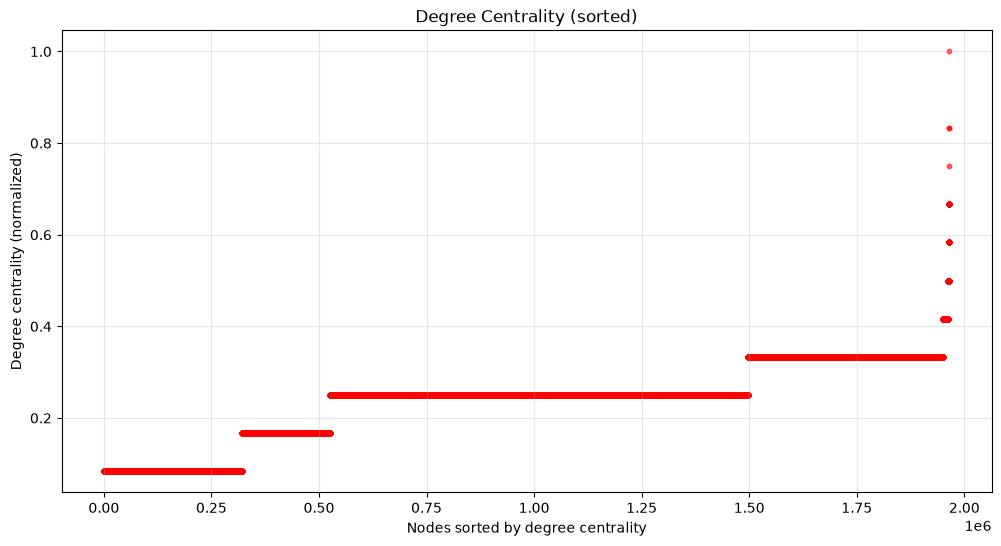

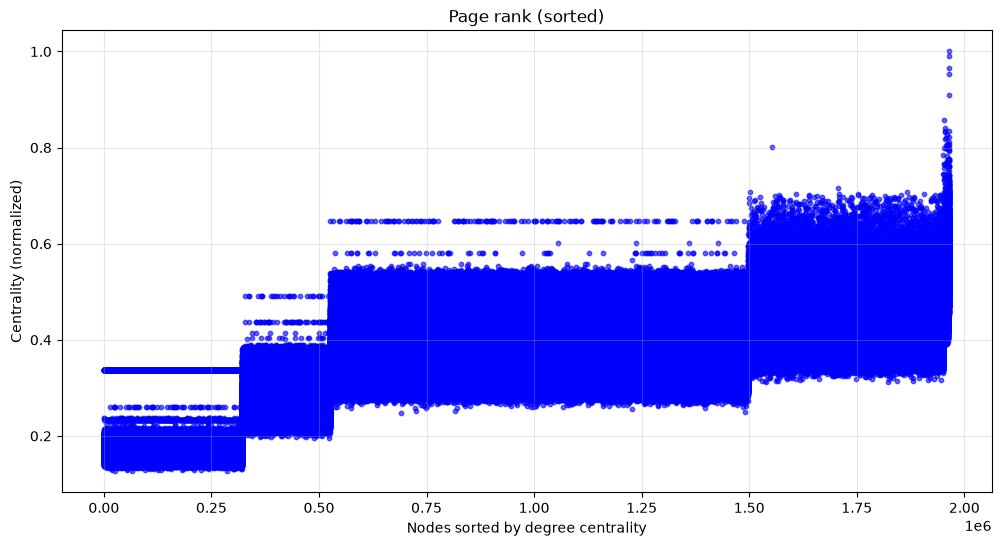

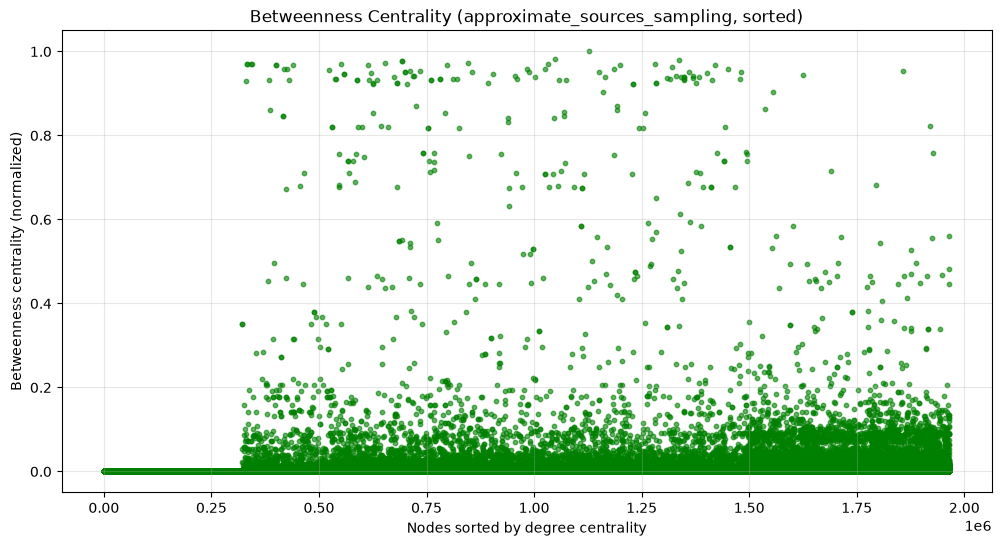

In [11]:


import numpy as np
import matplotlib.pyplot as plt

#Centralities
N = res["N"]
node_ids = np.arange(N)

#Degree centrality 
deg = np.array([res["degree_centrality"][i] for i in node_ids])

# Eigenvector centrality 
if "eigenvector_centrality" in res:
    eig_v = np.array([res["eigenvector_centrality"][i] for i in node_ids])

# PageRank  
eig_pr = np.array([res["pagerank"][i] for i in node_ids])

# Betweenness centrality

bet = np.array([res["betweenness_centrality"][i] for i in node_ids])


# Normalizzazione
deg = deg / deg.max() if deg.max() > 0 else deg
if "eigenvector_centrality" in res:
    eig_v = eig_v / eig_v.max() if eig_v.max() > 0 else eig_v
eig_pr = eig_pr / eig_pr.max() if eig_pr.max() > 0 else eig_pr
bet = bet / bet.max() if bet.max() > 0 else bet

# Ordino i nodi secondo la degree centrality
order = np.argsort(deg)

deg_sorted = deg[order]
if "eigenvector_centrality" in res:
    eig_v_sorted = eig_v[order]
eig_pr_sorted=eig_pr[order]
bet_sorted = bet[order]

# --- plot 1: Degree centrality ---
plt.figure(figsize=(12,6))
plt.scatter(range(len(deg_sorted)), deg_sorted, color="red", s=10, alpha=0.6)
plt.title("Degree Centrality (sorted)")
plt.xlabel("Nodes sorted by degree centrality")
plt.ylabel("Degree centrality (normalized)")
plt.grid(alpha=0.3)
plt.show()

# --- plot 2: Eigenvector / Page Rank---
if "eigenvector_centrality" in res:
    title = "Eigenvector Centrality (sorted)" 

    plt.figure(figsize=(12,6))
    plt.scatter(range(len(eig_v_sorted)), eig_v_sorted, color="blue", s=10, alpha=0.6)
    plt.title(title)
    plt.xlabel("Nodes sorted by degree centrality")
    plt.ylabel("Centrality (normalized)")
    plt.grid(alpha=0.3)
    plt.show()

title = "Page rank (sorted)" 
plt.figure(figsize=(12,6))
plt.scatter(range(len(eig_pr_sorted)), eig_pr_sorted, color="blue", s=10, alpha=0.6)
plt.title(title)
plt.xlabel("Nodes sorted by degree centrality")
plt.ylabel("Centrality (normalized)")
plt.grid(alpha=0.3)
plt.show()

# --- Grafico 3: Betweenness centrality ---
mode = res.get("betweenness_mode", "none")

plt.figure(figsize=(12,6))
plt.scatter(range(len(bet_sorted)), bet_sorted, color="green", s=10, alpha=0.6)
plt.title(f"Betweenness Centrality ({mode}, sorted)")
plt.xlabel("Nodes sorted by degree centrality")
plt.ylabel("Betweenness centrality (normalized)")
plt.grid(alpha=0.3)
plt.show()


Plot the degree distribution

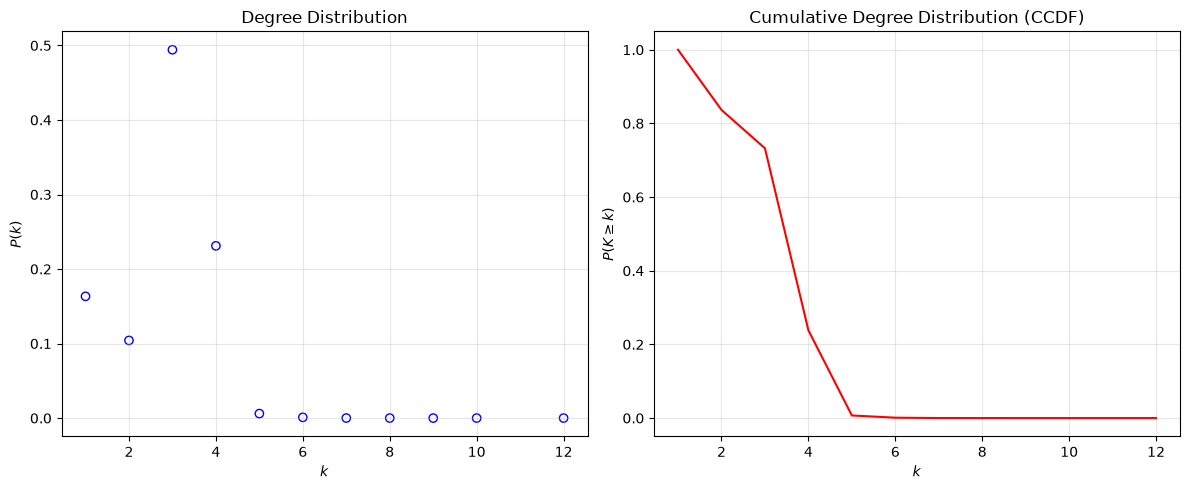

In [15]:
# Read degree sequence (one degree per line)
degrees = np.loadtxt("C:/Users/VALE/Documents/CN/forgithub/results/roadNet/roadNet-CA_results_degrees.txt", dtype=int)

N = len(degrees)

# ==========================
# P(k)
# ==========================

k_values, counts = np.unique(degrees, return_counts=True)
Pk = counts / N

# ==========================
# CCDF = P(K >= k)
# ==========================

degrees_sorted = np.sort(degrees)

ccdf = (
    N - np.searchsorted(degrees_sorted, k_values, side="left")
) / N

# ==========================
# Plot
# ==========================

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# P(k)
ax[0].scatter(
    k_values,
    Pk,
    marker="o",
    facecolors="none",
    edgecolors="blue"
)
# ax[0].set_xscale("log")  ### to get log-log graph
# ax[0].set_yscale("log")
ax[0].set_xlabel(r"$k$")
ax[0].set_ylabel(r"$P(k)$")
ax[0].set_title("Degree Distribution")
ax[0].grid(True, which="both", alpha=0.3)

# CCDF
ax[1].plot(
    k_values,
    ccdf,
    color="red",
    linewidth=1.5
)
# ax[1].set_xscale("log")    ### to get log-log graph
# ax[1].set_yscale("log")
ax[1].set_xlabel(r"$k$")
ax[1].set_ylabel(r"$P(K \geq k)$")
ax[1].set_title("Cumulative Degree Distribution (CCDF)")
ax[1].grid(True, which="both", alpha=0.3)
#plt.xlim(0, 100)

plt.tight_layout()

robustness function


In [16]:
import random

############################################
########### function to get <s> ############
############################################
def s_avg(sizes):

    if len(sizes) <= 1:
        return 0

    sizes = list(sizes)
    sizes.remove(max(sizes))

    return np.mean(sizes) if sizes else 0




#######################################################################
###### func to get S, s in function of f for rand, high k attack ######
#######################################################################

def robustness_analysis(
    G,
    outfile=None,
    dq=0.005,
    seed=None
):
    """
    Compute robustness under random failures and targeted attacks.

    Parameters
    ----------
    G : networkx.Graph
        Original graph.
    outfile : str
        Output txt file.
    dq : float
        Step size in q.
    seed : int or None
        Random seed.

    Returns
    -------
    result : dict
        Dictionary containing:
        f, S_rand, s_rand, S_att, s_att
    """

    if seed is not None:
        random.seed(seed)

    N = G.number_of_nodes()

    G_rand = G.copy()
    G_att = G.copy()

    f = []
    S_rand = []
    s_rand = []
    S_att = []
    s_att = []


    for q in np.arange(0, 1, dq):

        print(f"q = {q:.3f}")

        f.append(q)

        # ======================================================
        # RANDOM REMOVAL
        # ======================================================

        number_remno = int(dq*N)

        if number_remno > 0:

            nodes_to_remove = random.sample(
                list(G_rand.nodes()),
                min(number_remno, G_rand.number_of_nodes())
            )

            G_rand.remove_nodes_from(nodes_to_remove)


        if G_rand.number_of_nodes() > 0:

            connected_comp= list(nx.connected_components(G_rand))

            largest_cluster = max(
                connected_comp,
                key=len
            )

            S_rand.append(
                len(largest_cluster) /
                G_rand.number_of_nodes()
            )

            sizes = [len(c)for c in connected_comp]

            s_rand.append(s_avg(sizes))

        else:

            S_rand.append(0)
            s_rand.append(0)




        # ======================================================
        # Adaptive Degree Attack
        # ======================================================

        number_remno = int(dq*N)
        ordered_nodes = [
                    node for node, deg in
                    sorted(
                        G_att.degree,
                        key=lambda x: x[1],
                        reverse=True
                    )
                ]


        if number_remno > 0:

            G_att.remove_nodes_from(
                ordered_nodes[:number_remno]
            )


        if G_att.number_of_nodes() > 0:

            connected_comp= list(nx.connected_components(G_att))

            largest_cluster = max(
                connected_comp,
                key=len
            )

            S_att.append(
                len(largest_cluster) /
                G_att.number_of_nodes()
            )

            sizes = [len(c)for c in connected_comp]

            s_att.append(s_avg(sizes))

        else:

            S_att.append(0)
            s_att.append(0)

    # ==========================================================
    # SAVE TO FILE
    # ==========================================================

    data = np.column_stack([
        f,
        S_rand,
        s_rand,
        S_att,
        s_att
    ])

    np.savetxt(
        outfile,
        data,
        fmt="%.6f",
        header="f S_rand s_rand S_att s_att",
        comments=""
    )

    return {
        "f": np.array(f),
        "S_rand": np.array(S_rand),
        "s_rand": np.array(s_rand),
        "S_att": np.array(S_att),
        "s_att": np.array(s_att)
    }


Attack response of the PG network


q = 0.000
q = 0.005
q = 0.010
q = 0.015
q = 0.020
q = 0.025
q = 0.030
q = 0.035
q = 0.040
q = 0.045
q = 0.050
q = 0.055
q = 0.060
q = 0.065
q = 0.070
q = 0.075
q = 0.080
q = 0.085
q = 0.090
q = 0.095
q = 0.100
q = 0.105
q = 0.110
q = 0.115
q = 0.120
q = 0.125
q = 0.130
q = 0.135
q = 0.140
q = 0.145
q = 0.150
q = 0.155
q = 0.160
q = 0.165
q = 0.170
q = 0.175
q = 0.180
q = 0.185
q = 0.190
q = 0.195
q = 0.200
q = 0.205
q = 0.210
q = 0.215
q = 0.220
q = 0.225
q = 0.230
q = 0.235
q = 0.240
q = 0.245
q = 0.250
q = 0.255
q = 0.260
q = 0.265
q = 0.270
q = 0.275
q = 0.280
q = 0.285
q = 0.290
q = 0.295
q = 0.300
q = 0.305
q = 0.310
q = 0.315
q = 0.320
q = 0.325
q = 0.330
q = 0.335
q = 0.340
q = 0.345
q = 0.350
q = 0.355
q = 0.360
q = 0.365
q = 0.370
q = 0.375
q = 0.380
q = 0.385
q = 0.390
q = 0.395
q = 0.400
q = 0.405
q = 0.410
q = 0.415
q = 0.420
q = 0.425
q = 0.430
q = 0.435
q = 0.440
q = 0.445
q = 0.450
q = 0.455
q = 0.460
q = 0.465
q = 0.470
q = 0.475
q = 0.480
q = 0.485
q = 0.490
q = 0.495


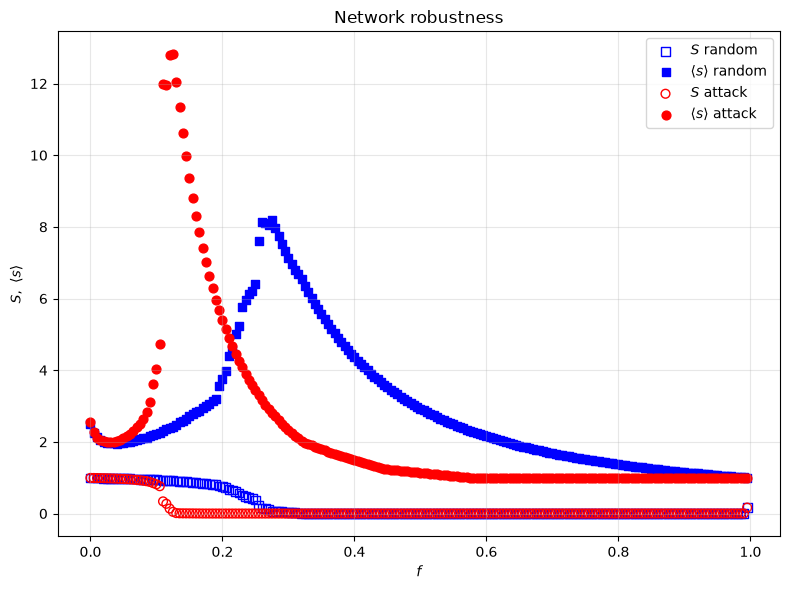

In [17]:
import igraph as ig
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

G_nx = nx.Graph()
G_nx.add_nodes_from(range(G.vcount()))
G_nx.add_edges_from(G.get_edgelist())

robustness = robustness_analysis(
    G_nx,
    outfile="C:/Users/VALE/Documents/CN/forgithub/results/roadNet/roadNet-CA_robustness.txt",
    dq=0.005,
    seed=56
)
data = np.loadtxt(
    "C:/Users/VALE/Documents/CN/forgithub/results/roadNet/roadNet-CA_robustness.txt",
    skiprows=1
)

f = data[:, 0]
S_rand = data[:, 1]
s_rand = data[:, 2]
S_att = data[:, 3]
s_att = data[:, 4]


#PLOT THE RESULTS

plt.figure(figsize=(8, 6))

# S random: empty blue squares
plt.scatter(
    f, S_rand,
    marker='s',
    facecolors='none',
    edgecolors='blue',
    s=40,
    label=r'$S$ random'
)

# <s> random: filled blue squares
plt.scatter(
    f, s_rand,
    marker='s',
    color='blue',
    s=40,
    label=r'$\langle s \rangle$ random'
)

# S attack: empty red circles
plt.scatter(
    f, S_att,
    marker='o',
    facecolors='none',
    edgecolors='red',
    s=40,
    label=r'$S$ attack'
)

# <s> attack: filled red circles
plt.scatter(
    f, s_att,
    marker='o',
    color='red',
    s=40,
    label=r'$\langle s \rangle$ attack'
)

plt.xlabel(r'$f$')
plt.ylabel(r'$S,\ \langle s \rangle$')
plt.title('Network robustness')
plt.legend()
plt.grid(True, alpha=0.3)

# LIMIT TO X AXIS
#plt.xlim(-0.05, 0.3)

plt.tight_layout()
plt.show()
